In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit
import re

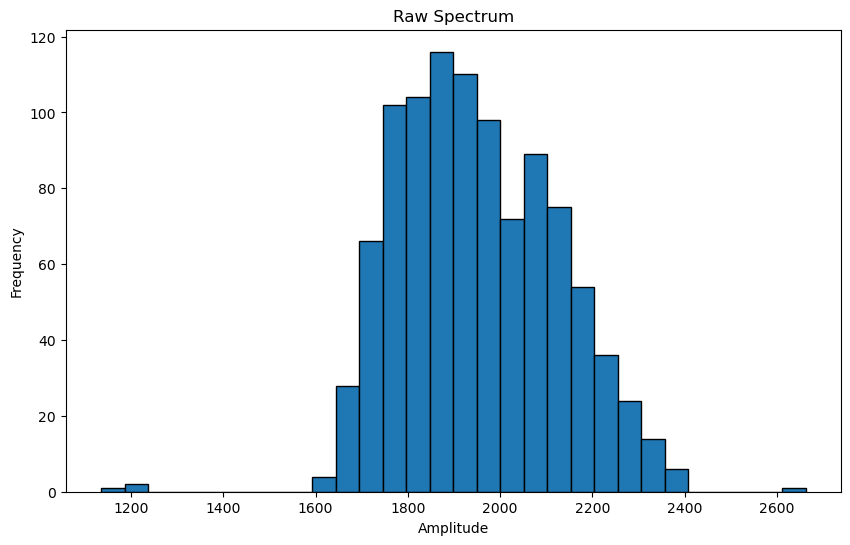

1002


In [2]:
# Read the .ntp file and plot histogram of amplitudes for one of the files
ntp_file = os.path.join('fwddata_ntuples', '20260120_16h59.BINNTD1.ntp')
data = np.loadtxt(ntp_file)
amplitudes = data[:, 1]  # Extract second column

plt.figure(figsize=(10, 6))
plt.hist(amplitudes, bins=30, edgecolor='black')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.title('Raw Spectrum')
plt.show()

print(len(amplitudes))

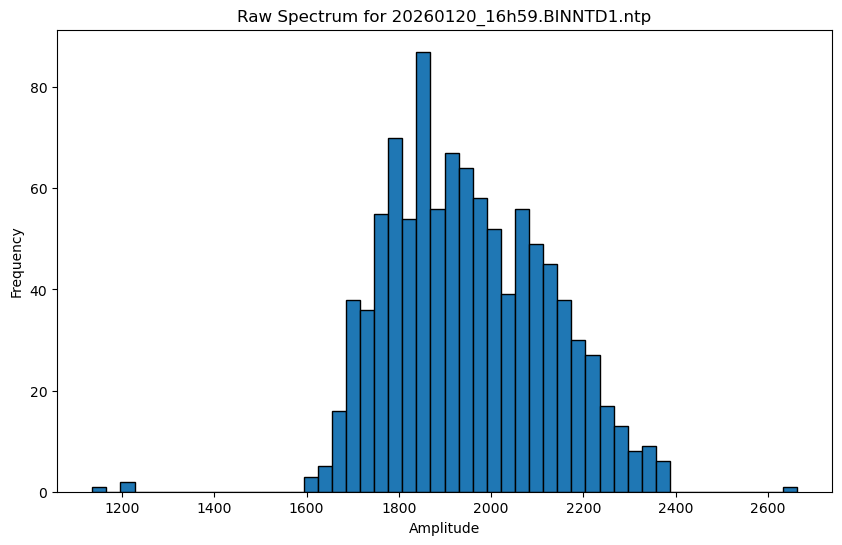

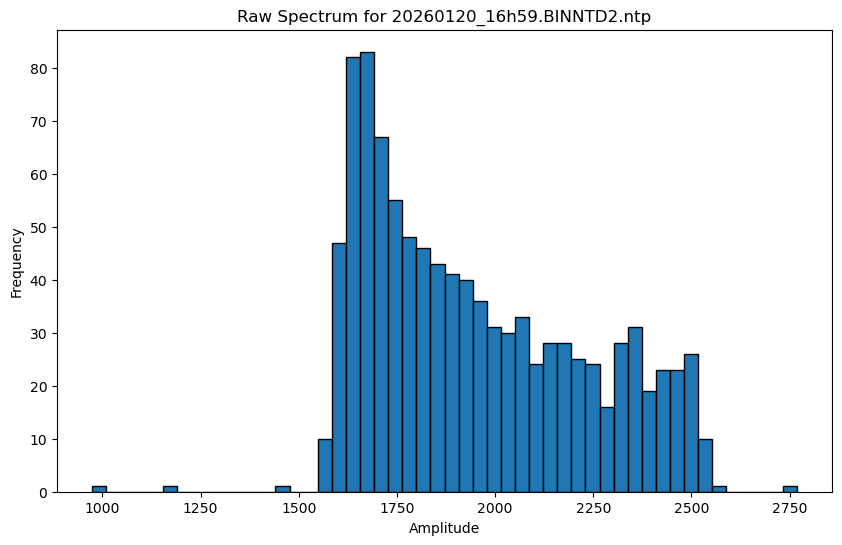

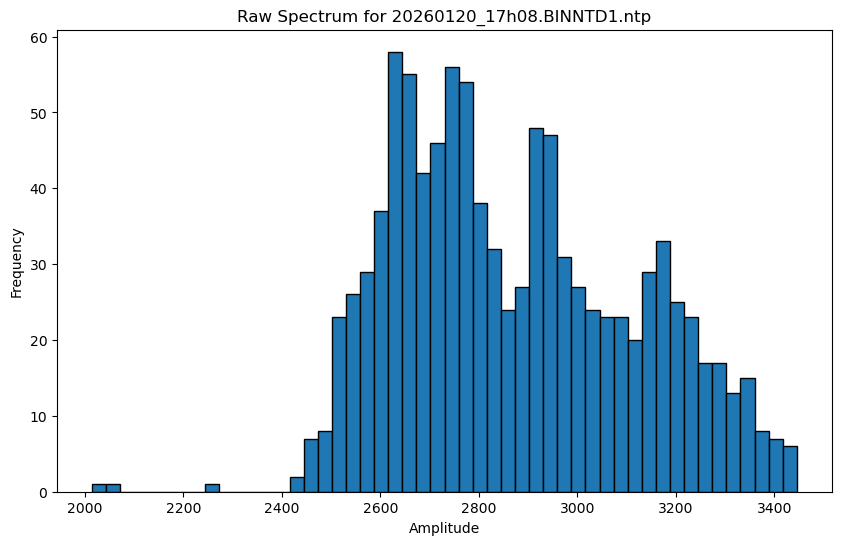

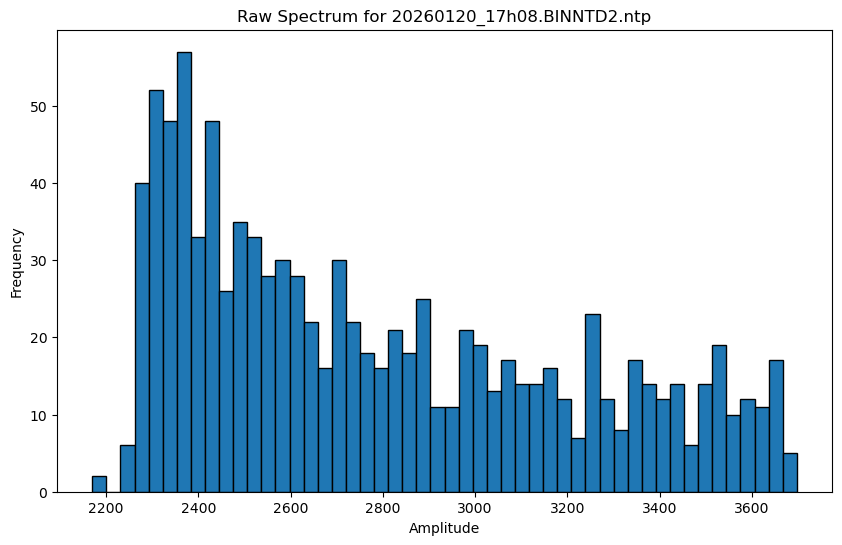

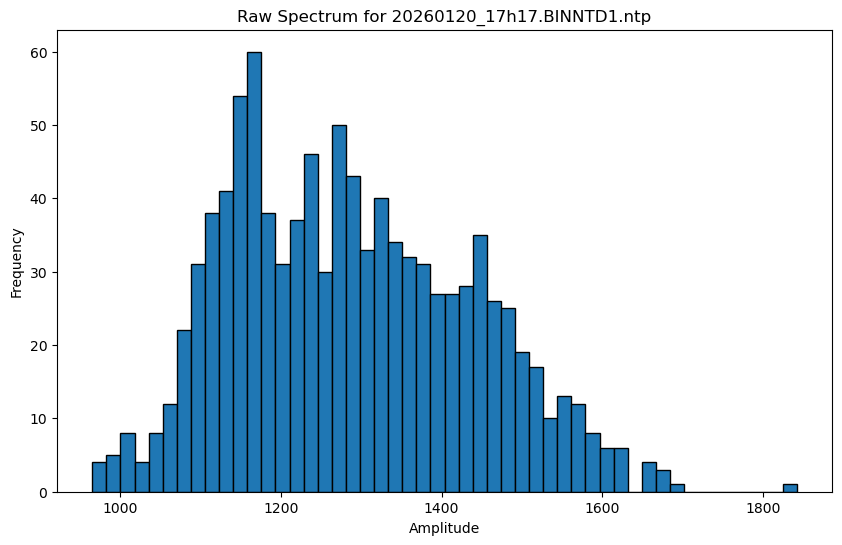

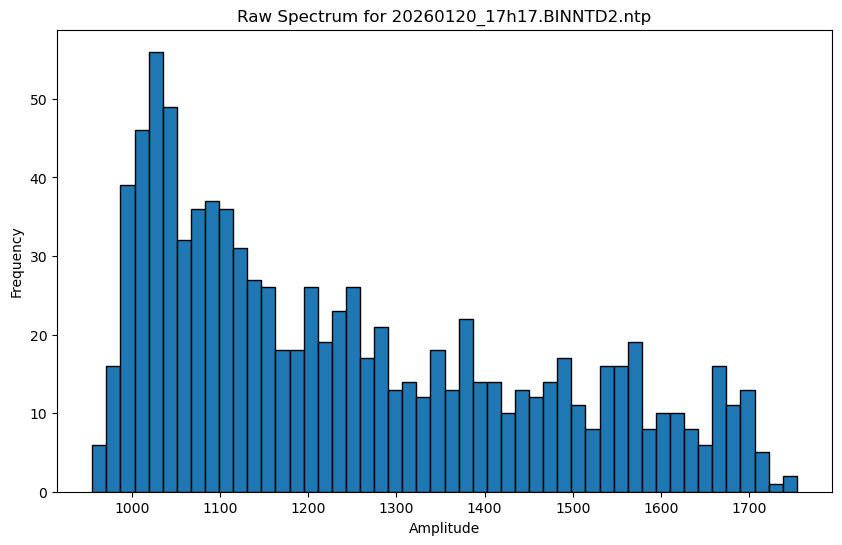

In [3]:
# Read the .ntp file and plot histogram of amplitudes for all the files
folder_name = 'fwddata_ntuples'
for filename in os.listdir(folder_name):
    ntp_file = os.path.join(folder_name, filename)
    data = np.loadtxt(ntp_file)
    amplitudes = data[:, 1]  # Extract second column

    plt.figure(figsize=(10, 6))
    plt.hist(amplitudes, bins=50, edgecolor='black')
    plt.xlabel('Amplitude')
    plt.ylabel('Frequency')
    plt.title('Raw Spectrum for ' + filename)
    plt.show()

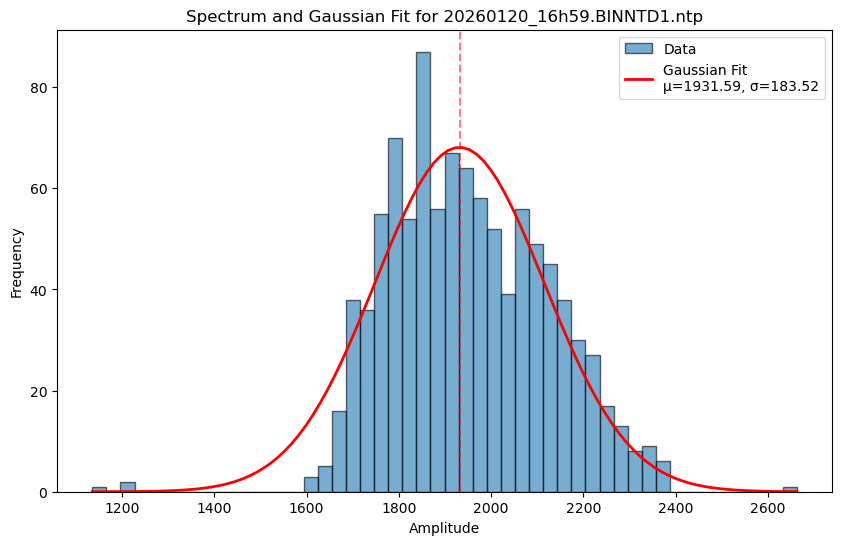

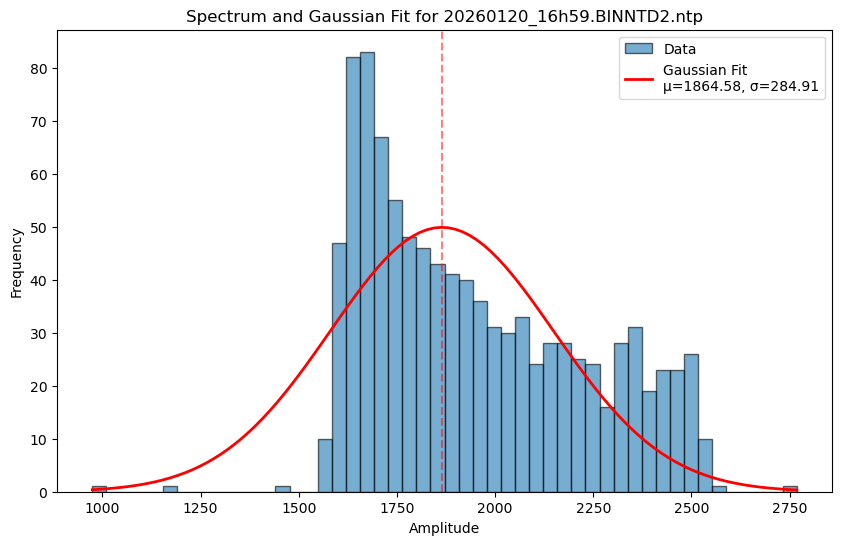

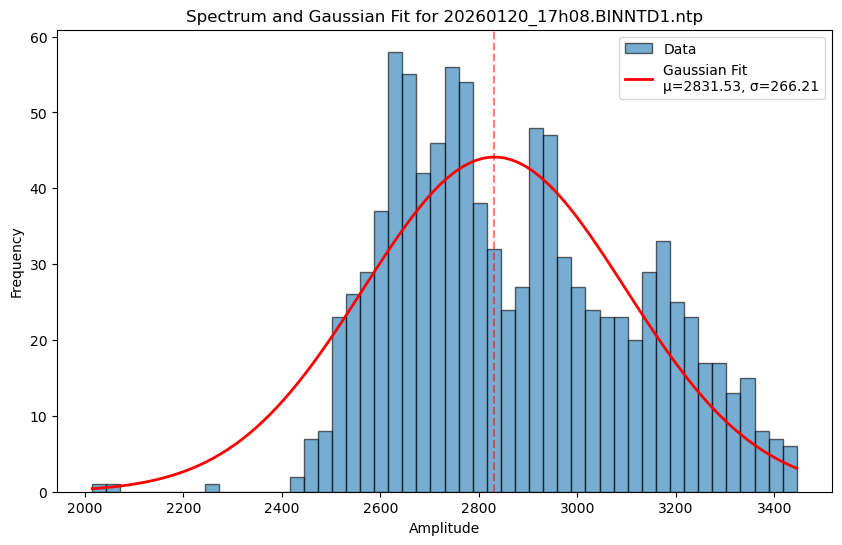

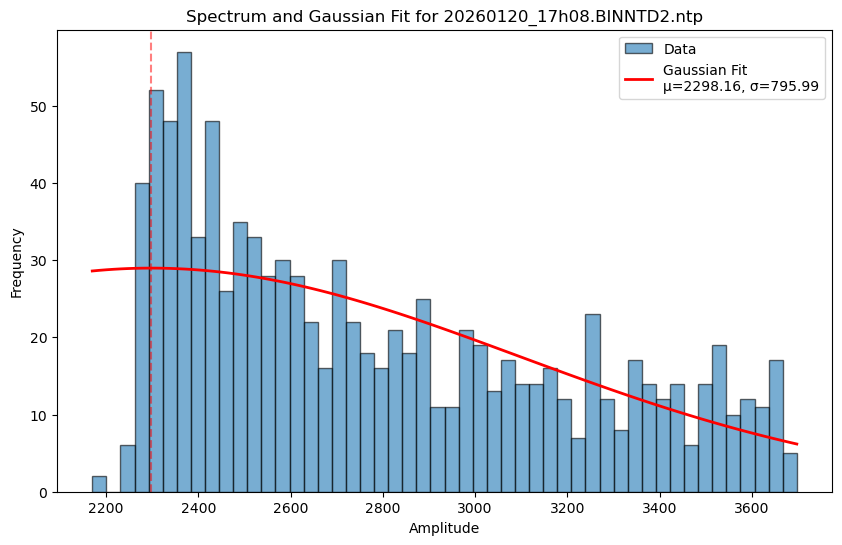

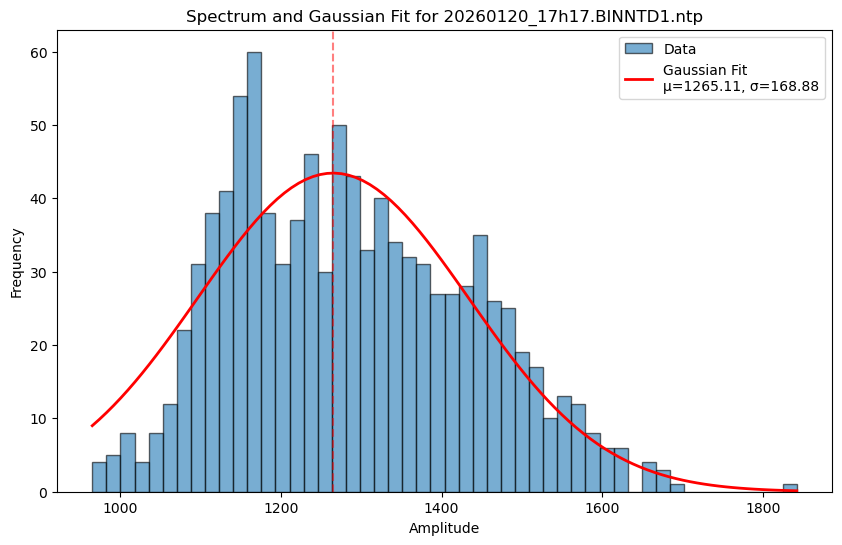

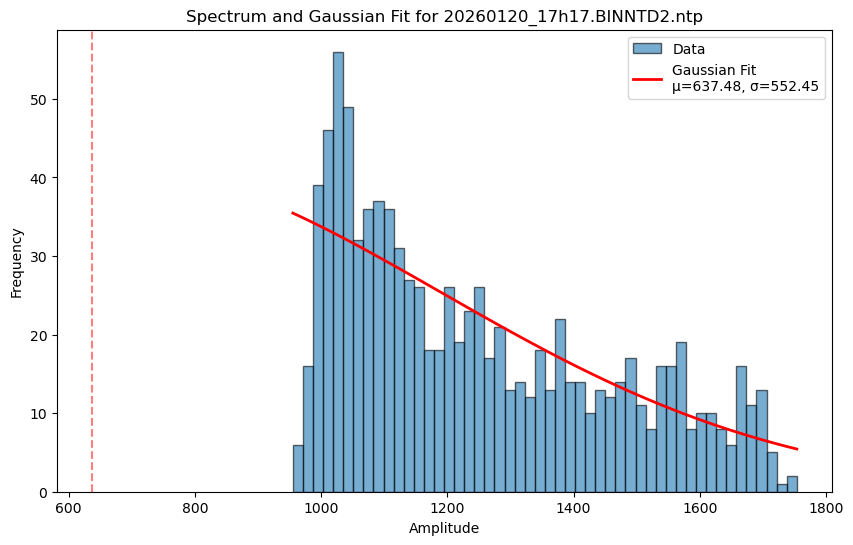

In [4]:
# Define the Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

folder_name = 'fwddata_ntuples'

for filename in os.listdir(folder_name):
    if filename.endswith(".ntp"):  # Good practice to filter files
        ntp_file = os.path.join(folder_name, filename)
        data = np.loadtxt(ntp_file)
        amplitudes = data[:, 1]

        plt.figure(figsize=(10, 6))
        
        # 1. Create the histogram and get bin data
        # counts is the y-axis, bins is the x-axis edges
        counts, bins, _ = plt.hist(amplitudes, bins=50, edgecolor='black', alpha=0.6, label='Data')
        
        # 2. Calculate bin centers (needed for the x-values of the fit)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # 3. Provide initial guesses for the fit [amplitude, mean, sigma]
        initial_guess = [np.max(counts), np.mean(amplitudes), np.std(amplitudes)]

        try:
            # 4. Perform the fit
            popt, _ = curve_fit(gaussian, bin_centers, counts, p0=initial_guess)
            
            # Generate points for the smooth fit line
            x_fit = np.linspace(bins[0], bins[-1], 100)
            y_fit = gaussian(x_fit, *popt)

            # 5. Plot the fit
            plt.plot(x_fit, y_fit, color='red', lw=2, label=f'Gaussian Fit\nμ={popt[1]:.2f}, σ={popt[2]:.2f}')
            plt.axvline(popt[1], color='red', linestyle='--', alpha=0.5) # Line at the mean
            
        except RuntimeError:
            print(f"Could not fit Gaussian for {filename}")

        plt.xlabel('Amplitude')
        plt.ylabel('Frequency')
        plt.title(f'Spectrum and Gaussian Fit for {filename}')
        plt.legend()
        plt.show()

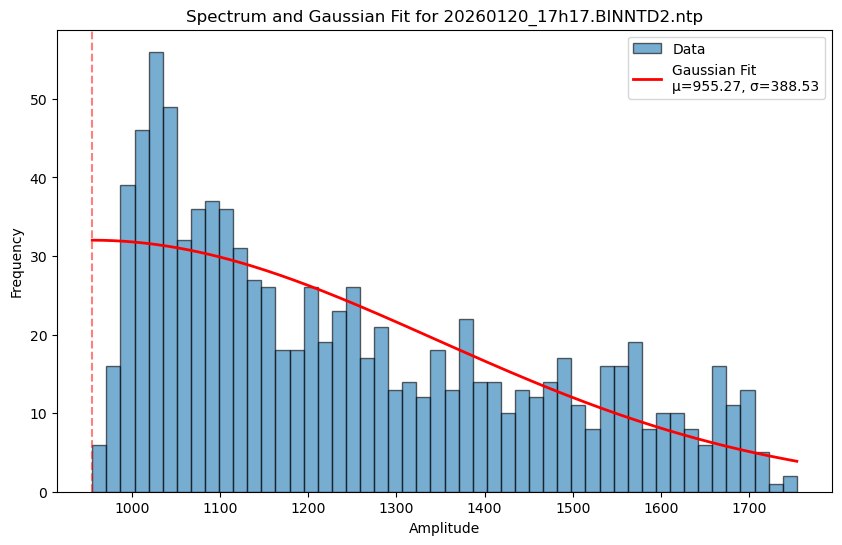

[ 32.01353978 955.271026   388.53179302]


In [5]:
# Define the Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

# --- SETTINGS ---
folder_name = 'fwddata_ntuples'
filename = '20260120_17h17.BINNTD2.ntp'  # <--- REPLACE THIS with your specific file name
# ----------------

# Construct the full path to the single file
ntp_file = os.path.join(folder_name, filename)

# Check if file exists to avoid errors
if os.path.exists(ntp_file):
    
    # Load data
    data = np.loadtxt(ntp_file)
    amplitudes = data[:, 1]
    
    amplitudes = amplitudes[amplitudes > 10]  # Filter out low amplitudes to reduce noise

    plt.figure(figsize=(10, 6))
    
    # 1. Create the histogram and get bin data
    counts, bins, _ = plt.hist(amplitudes, bins=50, edgecolor='black', alpha=0.6, label='Data')
    
    # 2. Calculate bin centers
    bin_centers = (bins[:-1] + bins[1:]) / 2

# --- THE FIX: RESTRICT FIT RANGE ---
    # We only fit the Gaussian to the data inside this window.
    # Looking at your graph, the peak is roughly between 900 and 1400.
    fit_min = 900
    fit_max = 1400
    
    # Create a "mask" to select only the bin centers inside that range
    mask = (bin_centers > fit_min) & (bin_centers < fit_max)
    
    x_for_fit = bin_centers[mask]
    y_for_fit = counts[mask]

    # 3. Provide initial guesses [amplitude, mean, sigma]
    # OLD WAY: np.mean(amplitudes) can be misleading if data is skewed
    # initial_guess = [np.max(counts), np.mean(amplitudes), np.std(amplitudes)]
    
    # NEW WAY: Use the bin with the highest count as the starting mean
    peak_bin_index = np.argmax(counts)
    peak_value_guess = bin_centers[peak_bin_index]
    sigma_guess = 200  # A reasonable fixed guess for sigma
    guess_amp = np.max(y_for_fit)
    guess_mean = x_for_fit[np.argmax(y_for_fit)]
    
    initial_guess = [guess_amp, guess_mean, sigma_guess]

    try:
        # 4. Perform the fit with bounds
        # Bounds: ([low_amp, low_mean, low_sigma], [high_amp, high_mean, high_sigma])
        # We constrain mean to be within the data range (min to max x)
        popt, _ = curve_fit(
            gaussian, 
            bin_centers, 
            counts, 
            p0=initial_guess,
            bounds=([0, min(bins), 0], [np.inf, max(bins), np.inf]) 
        )

        # Generate points for the smooth fit line
        x_fit = np.linspace(bins[0], bins[-1], 200)
        y_fit = gaussian(x_fit, *popt)

        # 5. Plot the fit
        plt.plot(x_fit, y_fit, color='red', lw=2, label=f'Gaussian Fit\nμ={popt[1]:.2f}, σ={popt[2]:.2f}')
        plt.axvline(popt[1], color='red', linestyle='--', alpha=0.5) 
        
    except RuntimeError:
        print(f"Could not fit Gaussian for {filename}")

    plt.xlabel('Amplitude')
    plt.ylabel('Frequency')
    plt.title(f'Spectrum and Gaussian Fit for {filename}')
    plt.legend()
    plt.show()

else:
    print(f"Error: The file '{filename}' was not found in folder '{folder_name}'.")

print(popt)

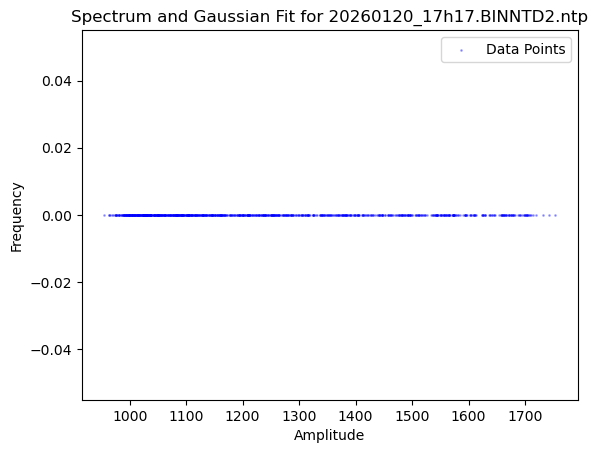

[ 32.01353138 955.271026   388.53200416]
955.271026 1753.71443
955.271026 1753.71443
1247.588539749737


In [6]:
# Define the Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

# --- SETTINGS ---
folder_name = 'fwddata_ntuples'
filename = '20260120_17h17.BINNTD2.ntp'  # <--- REPLACE THIS with your specific file name
# ----------------

# Construct the full path to the single file
ntp_file = os.path.join(folder_name, filename)

# Check if file exists to avoid errors
if os.path.exists(ntp_file):
    
    # Load data
    data = np.loadtxt(ntp_file)
    amplitudes = data[:, 1]

    
    # 1. Create the histogram and get bin data
    
    # 2. Calculate bin centers
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # 3. Provide initial guesses [amplitude, mean, sigma]
    # OLD WAY: np.mean(amplitudes) can be misleading if data is skewed
    # initial_guess = [np.max(counts), np.mean(amplitudes), np.std(amplitudes)]
    
    # NEW WAY: Use the bin with the highest count as the starting mean
    peak_bin_index = np.argmax(counts)
    peak_value_guess = bin_centers[peak_bin_index]
    sigma_guess = np.std(amplitudes) 
    
    initial_guess = [np.max(counts), peak_value_guess, sigma_guess]

    try:
        # 4. Perform the fit with bounds
        # Bounds: ([low_amp, low_mean, low_sigma], [high_amp, high_mean, high_sigma])
        # We constrain mean to be within the data range (min to max x)
        popt, _ = curve_fit(
            gaussian, 
            bin_centers, 
            counts, 
            p0=initial_guess,
            bounds=([0, min(bins), 0], [np.inf, max(bins), np.inf]) 
        )

        # Generate points for the smooth fit line
        x_fit = np.linspace(bins[0], bins[-1], 100)
        y_fit = gaussian(x_fit, *popt)

        # 5. Plot the fit
        plt.scatter(amplitudes, np.zeros_like(amplitudes), color='blue', s=1, alpha=0.3, label='Data Points')
        
    except RuntimeError:
        print(f"Could not fit Gaussian for {filename}")

    plt.xlabel('Amplitude')
    plt.ylabel('Frequency')
    plt.title(f'Spectrum and Gaussian Fit for {filename}')
    plt.legend()
    plt.show()

else:
    print(f"Error: The file '{filename}' was not found in folder '{folder_name}'.")

print(popt)
print(min(bins), max(bins))
print(min(amplitudes), max(amplitudes))
print(np.mean(amplitudes))